In [18]:
# Essential libraries for data handling, visualization, and modeling

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)


In [19]:
# Upload 'advertising.csv' using the left panel in Google Colab before running this cell.

df = pd.read_csv("advertising.csv")

print("Dataset loaded. Preview of first rows:")
df.head()


Dataset loaded. Preview of first rows:


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [20]:
print("\nGeneral Dataset Information:\n")
df.info()

print("\nStatistical Overview:\n")
df.describe()



General Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB

Statistical Overview:



,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [21]:
print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


In [22]:
print("Columns present in the dataset:")
print(df.columns.tolist())


Columns present in the dataset:
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country', 'Timestamp', 'Clicked on Ad']


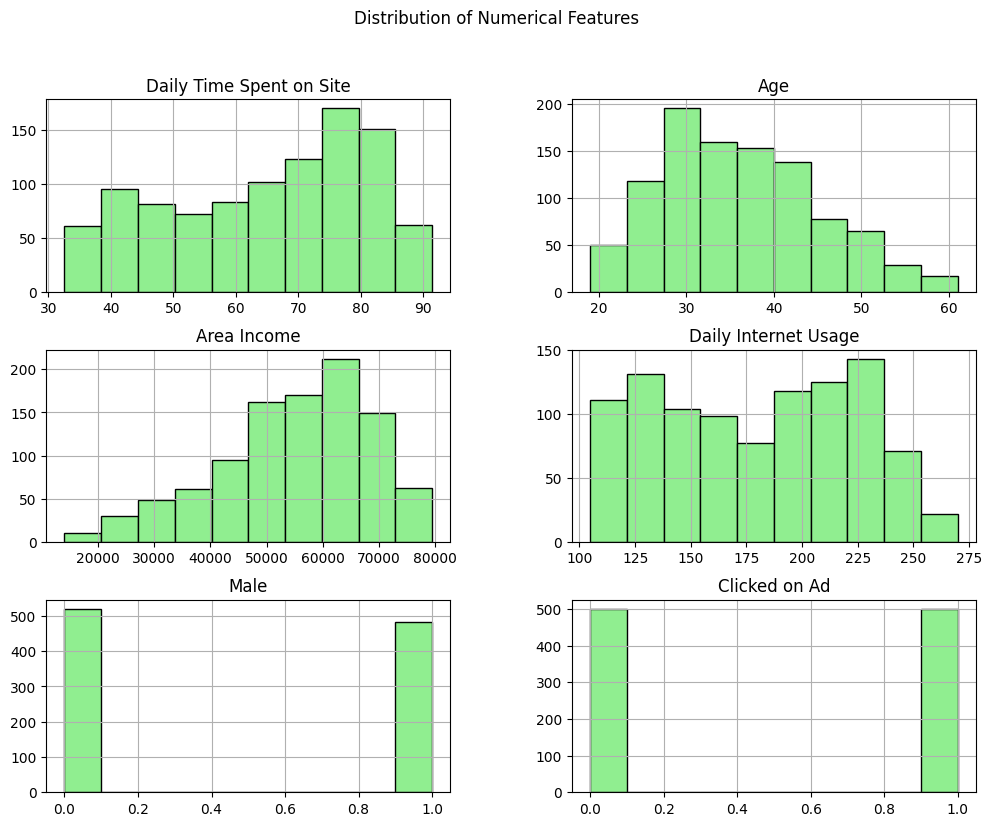

In [23]:
df.hist(figsize=(12, 9), color="lightgreen", edgecolor="black")
plt.suptitle("Distribution of Numerical Features")
plt.show()


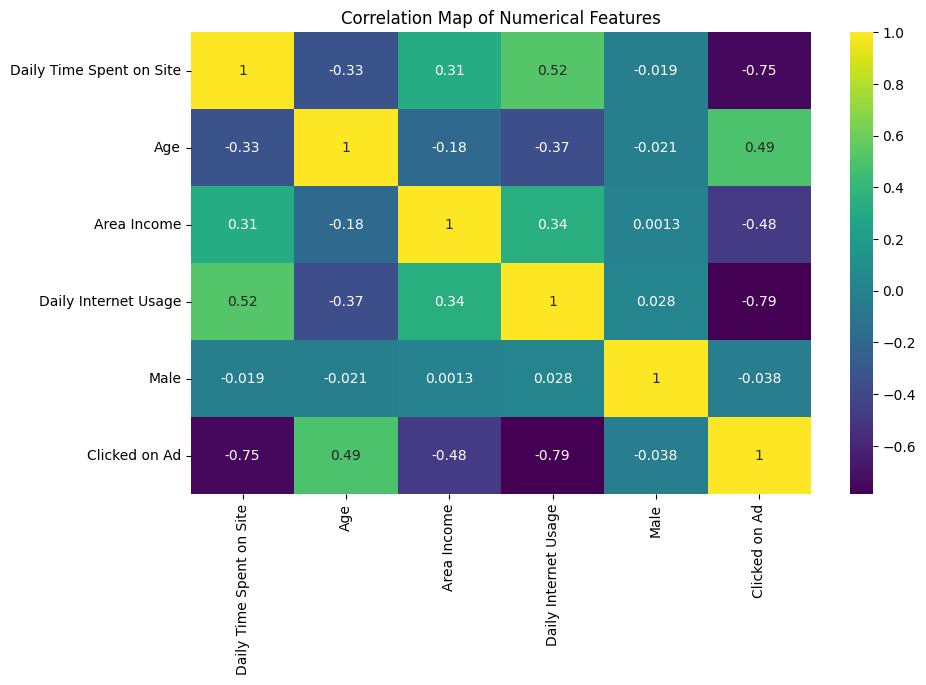

In [24]:
plt.figure(figsize=(10, 6))
# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="viridis")
plt.title("Correlation Map of Numerical Features")
plt.show()

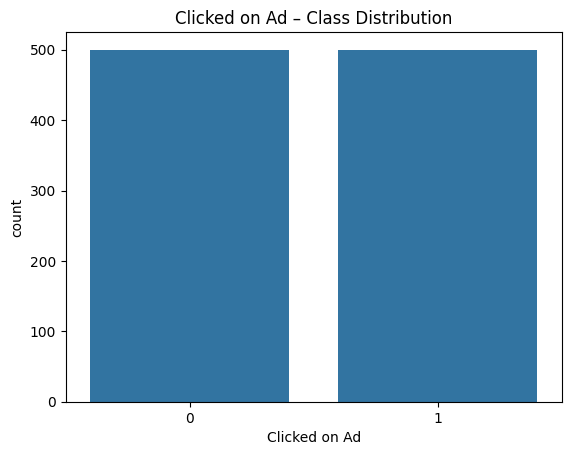

Class Frequency:
 Clicked on Ad
0    500
1    500
Name: count, dtype: int64


In [25]:
sns.countplot(x=df["Clicked on Ad"])
plt.title("Clicked on Ad – Class Distribution")
plt.show()

print("Class Frequency:\n", df["Clicked on Ad"].value_counts())


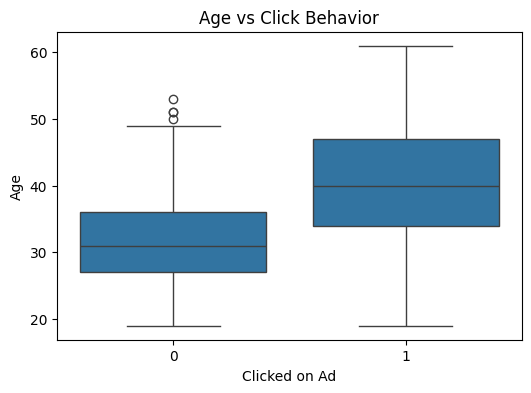

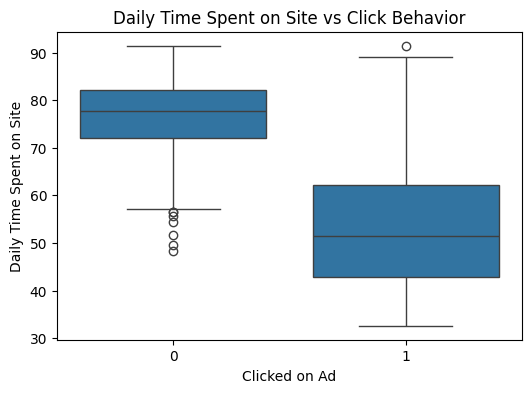

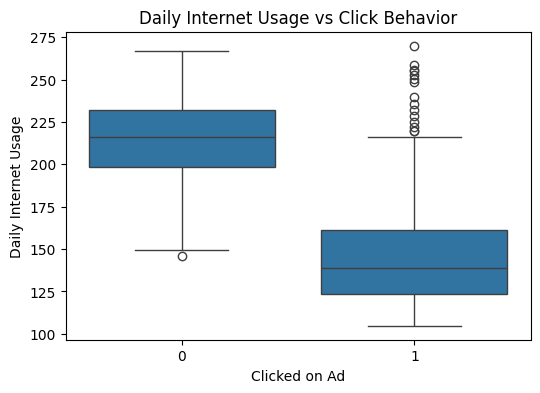

In [26]:
# Boxplots to see how features vary across target categories

features_to_plot = ["Age", "Daily Time Spent on Site", "Daily Internet Usage"]

for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Clicked on Ad", y=feature, data=df)
    plt.title(f"{feature} vs Click Behavior")
    plt.show()


In [27]:
X = df[["Daily Time Spent on Site",
        "Age",
        "Area Income",
        "Daily Internet Usage",
        "Male"]]

y = df["Clicked on Ad"]

print("Selected Feature Matrix (X):")
print(X.head())


Selected Feature Matrix (X):
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  Male
0                     68.95   35     61833.90                256.09     0
1                     80.23   31     68441.85                193.77     1
2                     69.47   26     59785.94                236.50     0
3                     74.15   29     54806.18                245.89     1
4                     68.37   35     73889.99                225.58     0


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=10)

print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)


Training Set Shape: (700, 5)
Test Set Shape: (300, 5)


In [29]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

print("Model has been fitted to the training data.")


Model has been fitted to the training data.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
y_pred = log_model.predict(X_test)

print("Sample predictions:", y_pred[:8])


Sample predictions: [1 1 0 0 1 1 0 0]


In [31]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print("Performance Metrics:")
print("---------------------")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Performance Metrics:
---------------------
Accuracy : 0.9000
Precision: 0.9247
Recall   : 0.8766

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       146
           1       0.92      0.88      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



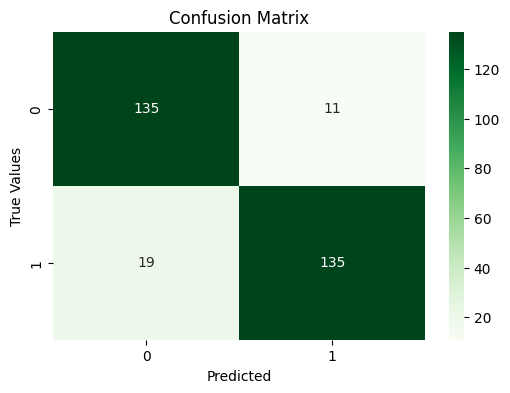

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Greens", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True Values")
plt.show()


In [33]:
print("""
 KEY TAKEAWAYS FROM THE MODEL
-------------------------------------

1. Logistic Regression turned out to be suitable for predicting user
   click behavior since the output is binary.

2. Features such as Daily Time Spent on Site, Age, and Internet Usage
   show strong patterns with respect to ad-click likelihood.

3. Model performance was solid, with high accuracy, precision,
   and recall—indicating reliable predictions.

4. The model can assist ConnectSphere Digital in filtering out users
   who are unlikely to click, helping optimize marketing budgets.

5. This translates to better CTR, reduced wastage, and more efficient
   campaign performance.

 Overall, the project successfully builds a predictive system that supports
data-driven decision-making for online advertising.
""")



 KEY TAKEAWAYS FROM THE MODEL
-------------------------------------

1. Logistic Regression turned out to be suitable for predicting user
   click behavior since the output is binary.

2. Features such as Daily Time Spent on Site, Age, and Internet Usage
   show strong patterns with respect to ad-click likelihood.

3. Model performance was solid, with high accuracy, precision,
   and recall—indicating reliable predictions.

4. The model can assist ConnectSphere Digital in filtering out users
   who are unlikely to click, helping optimize marketing budgets.

5. This translates to better CTR, reduced wastage, and more efficient
   campaign performance.

 Overall, the project successfully builds a predictive system that supports
data-driven decision-making for online advertising.

